<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1%EB%B0%8F%EB%B6%84%EC%84%9D(test).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
print("훈련 데이터 : ")
print("train_scaeld.shape, train_target.shape")
print("테스트 데이터 : ")
print("test_scaeld.shape, test_target.shape")
print("검증 데이터 : ")
print("val_scaeld.shape, val_target.shape")

훈련 데이터 : 
train_scaeld.shape, train_target.shape
테스트 데이터 : 
test_scaeld.shape, test_target.shape
검증 데이터 : 
val_scaeld.shape, val_target.shape


In [3]:
# 모델을 생성하는 함수를 정의한다.
def model_fn(a_layer=None) :
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    model.add(keras.layers.Dense(100, activation='relu'))

    # 'model_fn' 함수에 'a_layer' 매개변수를 통해 케라스 층을 추가하면, 은닉층 뒤에 하나의 층을 추가한다.
    if a_layer :
      model.add(a_layer) # 매개 값으로 넘어오며 추가되는 층
    model.add(keras.layers.Dense(10, activation='softmax')) # 반복적으로 사용되는 다중 분류층
    return model

In [7]:
# 앞서 생성한 매서드를 호출하여 'model' 변수에 담는다.
model = model_fn()

model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#                              다중 분류                         정확도

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# 'fit' 매서드의 결과를 'history' 변수에 담는다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=2)

Epoch 1/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8109 - loss: 0.5377
Epoch 2/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8565 - loss: 0.3983
Epoch 3/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8706 - loss: 0.3585
Epoch 4/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8798 - loss: 0.3346
Epoch 5/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8883 - loss: 0.3156


In [21]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

In [14]:
# 'model_fn' 함수에 드롭아웃 객체를 전달하여 층을 추가한다.
model = model_fn(keras.layers.Dropout(0.3)) # 30%를 드롭아웃 한다.

In [15]:
model.summary() # 모델의 요약된 정보를 출력한다.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

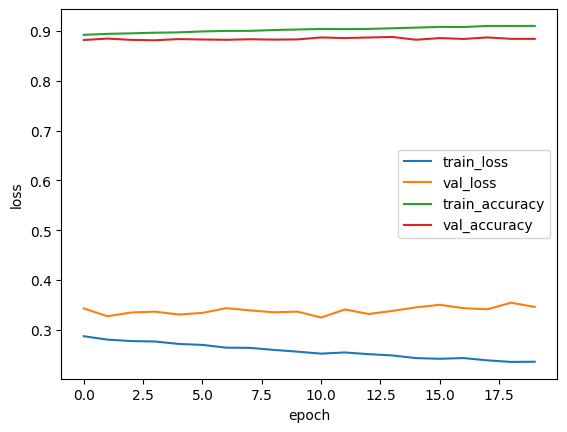

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()
plt.show()

In [16]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

model.save('model-whole-ep10.keras') # 모델을 저장한다.

In [17]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42) # 실행마다 동일한 결과를 얻기 위해, 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 만든다.

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data() # 패션 MNIST 데이터를 불러온다.

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
# train_input(48000, 28, 28) → train_scaled(48000, 28, 28, 1) (4차원)
#                                                         흑백

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [18]:
# 모델을 컴파일 하고 훈련한다.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 아담 최적화로 훈련한다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)

# 검증이 2번 정도 상향 시 조기 종료를 한다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)

# EarlyStopping 콜백을 통해 조기 종료를 한다.
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8826 - loss: 0.3128 - val_accuracy: 0.8793 - val_loss: 0.3313
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8850 - loss: 0.3053 - val_accuracy: 0.8807 - val_loss: 0.3291
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8863 - loss: 0.3035 - val_accuracy: 0.8832 - val_loss: 0.3280
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8888 - loss: 0.2999 - val_accuracy: 0.8842 - val_loss: 0.3298
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8926 - loss: 0.2889 - val_accuracy: 0.8808 - val_loss: 0.3267
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8919 - loss: 0.2862 - val_accuracy: 0.8796 - val_loss: 0.3384
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8931 - loss: 0.2833 - val_accuracy: 0.8801 - val_loss: 0.3393


In [23]:
# 테스트 세트를 통해 합성곱 신경망의 일반화 성능을 파악한다.
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8784 - loss: 0.3871


[0.3864157497882843, 0.876800000667572]

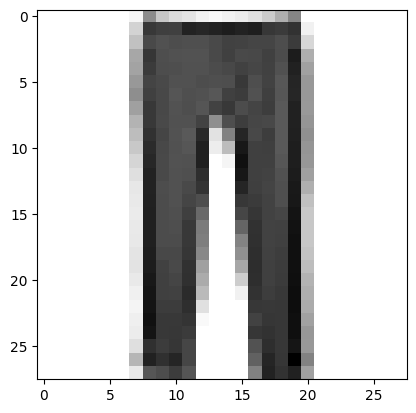

In [27]:
# 크기를 (28, 28, 1)에서 (28, 28)로 변경한다.
plt.imshow(val_scaled[15].reshape(28, 28), cmap='gray_r')
plt.show()